In [1]:
import cv2
import numpy as np

In [62]:
!gdown https://github.com/fannymonori/TF-ESPCN/blob/master/export/ESPCN_x2.pb

Downloading...
From: https://github.com/fannymonori/TF-ESPCN/blob/master/export/ESPCN_x2.pb
To: C:\Users\rusan\Documents\GitHub\cv-qpi\ESPCN_x2.pb

0.00B [00:00, ?B/s]
224kB [00:00, 3.46MB/s]


## Video Upscaling

In [65]:
import cv2
import numpy as np

def upscale_video(input_path, output_path=None, scale=2, interpolation=cv2.INTER_LANCZOS4):

    cap = cv2.VideoCapture(input_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open video {input_path}")
        return None
    
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Original video: {width}x{height}, {fps} FPS, {total_frames} frames")
    
    new_width = width * scale
    new_height = height * scale
    
    if output_path is None:
        name, ext = input_path.rsplit('.', 1)
        output_path = f"{name}_upscaled_{scale}x.{ext}"
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (new_width, new_height))
    
    print(f"Output video: {output_path}")
    print(f"New size: {new_width}x{new_height}")
    
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        
        upscaled = cv2.resize(frame, (new_width, new_height), interpolation=interpolation)
        
        out.write(upscaled)
        
        if frame_count % 30 == 0:
            print(f"Processed: {frame_count}/{total_frames} ({100*frame_count/total_frames:.1f}%)")
    
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    
    print(f"Video saved: {output_path}")
    print(f"Output size: {new_width}x{new_height}")
    
    return output_path

In [67]:
upscale_video("Video_S1_Dylan_RBC_deformability.mp4", scale=2)

Original video: 512x512, 29 FPS, 237 frames
Output video: Video_S1_Dylan_RBC_deformability_upscaled_2x.mp4
New size: 1024x1024
Processed: 30/237 (12.7%)
Processed: 60/237 (25.3%)
Processed: 90/237 (38.0%)
Processed: 120/237 (50.6%)
Processed: 150/237 (63.3%)
Processed: 180/237 (75.9%)
Processed: 210/237 (88.6%)
Video saved: Video_S1_Dylan_RBC_deformability_upscaled_2x.mp4
Output size: 1024x1024


'Video_S1_Dylan_RBC_deformability_upscaled_2x.mp4'

## Video and Background Enhancement

In [71]:
def enhance_fringes_contrast(img, boost_factor=2.0, mask_radius=20, filter_radius=15):
    if img.dtype != np.float32 and img.dtype != np.float64:
        img_float = img.astype(np.float32)
    else:
        img_float = img
    
    fft = np.fft.fftshift(np.fft.fft2(img_float))
    h, w = img_float.shape
    cy, cx = h//2, w//2

    Y, X = np.ogrid[:h, :w]
    center_mask = (X-cx)**2 + (Y-cy)**2 <= mask_radius**2
    spectrum = np.abs(fft)
    spectrum_masked = spectrum.copy()
    spectrum_masked[center_mask] = 0

    max_y, max_x = np.unravel_index(np.argmax(spectrum_masked), spectrum_masked.shape)

    pos_mask = (Y - max_y)**2 + (X - max_x)**2 < filter_radius**2
    fft[pos_mask] *= boost_factor

    enhanced_img = np.abs(np.fft.ifft2(np.fft.ifftshift(fft)))
    
    enhanced_img = np.clip(enhanced_img, 0, 255)
    enhanced_img = enhanced_img.astype(np.uint8)
    
    return enhanced_img


In [73]:
def mask_center(img, radius = 10, rotation90 = 0):
    h, w = np.rot90(img, rotation90).shape
    cy, cx = h//2, w//2
    mask_radius = 15
    Y, X = np.ogrid[:h, :w]
    mask = ((X-cx)**2 + (Y-cy)**2 <= mask_radius**2) | ~((X >= cx) & (Y <= cy))
    mask = np.rot90(mask, rotation90)
    img_masked = img.copy()
    img_masked[mask] = 0
    return img_masked

In [75]:
def find_plus_one_order_position(img, mask_radius=15, rotation90 = 0):
    h, w = img.shape
    cy, cx = h//2, w//2
    spectrum_img = img.copy()
    spectrum_masked = mask_center(spectrum_img, rotation90=rotation90)
    f_y, f_x = np.unravel_index(np.argmax(spectrum_masked), spectrum_masked.shape)
    return f_x, f_y

In [77]:
def get_spectrum_image_from_fft(fft):
    return np.log(1 + np.abs(fft))
    

In [79]:
def filter_spectrum(fft, f_x, f_y, radius=20):
    h, w = fft.shape
    cy, cx = h//2, w//2

    filter_mask = np.zeros((h, w), dtype=bool)
    Y, X = np.ogrid[:h, :w]
    dist_sq = (Y - f_y)**2 + (X - f_x)**2
    filter_mask = dist_sq < radius**2
    fft_filtered = np.zeros_like(fft)
    fft_filtered[filter_mask] = fft[filter_mask]
    return fft_filtered

In [81]:
def center_spectrum(fft, f_x, f_y):
    h, w = fft.shape
    c_y, c_x = h//2, w//2
    spectrum_centred = np.roll(fft, -int(f_y - c_y), axis=0)
    spectrum_centred = np.roll(spectrum_centred, -int(f_x - c_x), axis=1)
    return spectrum_centred
    

In [83]:
def pixelVal(pix, r1, s1, r2, s2):
    if (0 <= pix and pix <= r1):
        return (s1 / r1) * pix
    elif (r1 < pix and pix <= r2):
        return ((s2 - s1) / (r2 - r1)) * (pix - r1) + s1
    else:
        return ((255 - s2) / (255 - r2)) * (pix - r2) + s2

pixelVal_vec = np.vectorize(pixelVal)


In [379]:
input_video = "Videos/Video_S1_Dylan_RBC_deformability.mp4"
output_video = "Videos/output.mp4"

cap = cv2.VideoCapture(input_video)

# Получаем параметры видео
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    enhanced = enhance_fringes_contrast(gray, boost_factor=2.0)

    r1 = 70
    s1 = 0
    r2 = 200
    s2 = 255
    
    blurM = cv2.medianBlur(enhanced, 5)
    
    contrast_stretched = pixelVal_vec(blurM, r1, s1, r2, s2).astype(np.uint8)

    enhanced_bgr = cv2.cvtColor(contrast_stretched, cv2.COLOR_GRAY2BGR)
    
    out.write(contrast_stretched)

cap.release()
out.release()
cv2.destroyAllWindows()

In [465]:
import cv2
import numpy as np
import os

input_video = "Videos/Video_S1_Dylan_RBC_deformability.mp4"
output_video = "Videos/enhanced_video.mp4"

if not os.path.exists(input_video):
    print(f"Error: file {input_video} not found")
    exit()

cap = cv2.VideoCapture(input_video)

if not cap.isOpened():
    print(f"Error: could not open video {input_video}")
    exit()

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video: {width}x{height}, {fps} FPS")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

if not out.isOpened():
    print(f"Error: could not create output file {output_video}")
    cap.release()
    exit()

frame_count = 0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    frame_count += 1
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    enhanced = enhance_fringes_contrast(gray, boost_factor=2.0)

    r1 = 70
    s1 = 0
    r2 = 200
    s2 = 255
    
    blurM = cv2.medianBlur(enhanced, 5)
    
    contrast_stretched = pixelVal_vec(blurM, r1, s1, r2, s2).astype(np.uint8)

    # Check 4: ensure frame is color for writing
    if len(contrast_stretched.shape) == 2:
        enhanced_bgr = cv2.cvtColor(contrast_stretched, cv2.COLOR_GRAY2BGR)
    else:
        enhanced_bgr = contrast_stretched
    
    out.write(enhanced_bgr)

    if frame_count % 30 == 0:
        print(f"Processed: {frame_count}/{total_frames}")

cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Done! Saved {frame_count} frames to {output_video}")

Video: 512x512, 29 FPS
Processed: 30/237
Processed: 60/237
Processed: 90/237
Processed: 120/237
Processed: 150/237
Processed: 180/237
Processed: 210/237
Done! Saved 237 frames to enhanced_video.mp4


In [89]:
img = cv2.imread(r"Images/Tracking/background2.png", cv2.IMREAD_GRAYSCALE)

enhanced = enhance_fringes_contrast(img, boost_factor=2.0)

blurM = cv2.medianBlur(enhanced, 5)

r1 = 70
s1 = 0
r2 = 200
s2 = 255
    
contrast_stretched = pixelVal_vec(blurM, r1, s1, r2, s2).astype(np.uint8)

enhanced_bgr = cv2.cvtColor(contrast_stretched, cv2.COLOR_GRAY2BGR)
cv2.imwrite("Images/Tracking/enhanced_background.png", enhanced_bgr)

True

# Motion tracking

In [91]:
import cv2
import numpy as np
import os
import shutil

def process_erythrocytes_in_groove(
    background_path="Images/Tracking/enhanced_background.png",
    video_path="output.mp4",
    threshold=15,
    min_area=200,
    max_area=1000,
    max_distance=60,
    max_missing=5,
    groove_top_left=(280, 200),
    groove_bottom_right=(450, 300),
    padding=5,
    output_dir="Images/Tracking/erythrocytes_in_groove",
    visualize=True
):
    if os.path.exists(output_dir):
        print(f"Clearing output directory: {output_dir}")
        shutil.rmtree(output_dir)
        print(f"Output directory cleared")
    
    os.makedirs(output_dir, exist_ok=True)
    
    background = cv2.imread(background_path, cv2.IMREAD_GRAYSCALE)
    if background is None:
        print(f"Error: Could not load background from {background_path}")
        return None
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return None
    
    tracks = {}
    next_id = 0
    entered_groove = set()
    
    def is_in_groove(centroid):
        x, y = centroid
        x1, y1 = groove_top_left
        x2, y2 = groove_bottom_right
        return x1 <= x <= x2 and y1 <= y <= y2
    
    def save_cropped_erythrocyte(track_id, frame, frame_num, bbox, centroid):
        x, y, w, h = bbox
        
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(frame.shape[1], x + w + padding)
        y2 = min(frame.shape[0], y + h + padding)
        
        cropped = frame[y1:y2, x1:x2]
        
        if cropped.size == 0:
            return None
        
        track_dir = os.path.join(output_dir, f"ID_{track_id}")
        os.makedirs(track_dir, exist_ok=True)
        
        in_groove_flag = is_in_groove(centroid)
        status = "IN_GROOVE" if in_groove_flag else "BEFORE_AFTER"
        filename = f"frame_{frame_num:06d}_{status}_pos_{centroid[0]}_{centroid[1]}.png"
        filepath = os.path.join(track_dir, filename)
        
        cv2.imwrite(filepath, cropped)
        return filepath
    
    def update_tracks(detected_objects, frame_num, frame):
        nonlocal tracks, next_id, entered_groove
        
        if len(detected_objects) == 0:
            to_remove = []
            for track_id, track in tracks.items():
                track['missing'] += 1
                if track['missing'] > max_missing:
                    to_remove.append(track_id)
            for track_id in to_remove:
                del tracks[track_id]
            return
        
        if len(tracks) == 0:
            for obj in detected_objects:
                in_groove_flag = is_in_groove(obj['centroid'])
                
                tracks[next_id] = {
                    'positions': [obj['centroid']],
                    'bboxes': [obj['bbox']],
                    'missing': 0,
                    'last_seen': frame_num,
                    'entered_groove': in_groove_flag
                }
                
                if in_groove_flag:
                    entered_groove.add(next_id)
                    print(f"[ID:{next_id}] ENTERED groove at frame {frame_num}")
                
                save_cropped_erythrocyte(next_id, frame, frame_num, obj['bbox'], obj['centroid'])
                
                next_id += 1
            return
        
        matched_tracks = set()
        matched_objects = set()
        
        for obj_idx, obj in enumerate(detected_objects):
            best_track = None
            best_dist = max_distance
            
            for track_id, track in tracks.items():
                if track_id in matched_tracks:
                    continue
                
                last_pos = track['positions'][-1]
                dist = np.sqrt((obj['centroid'][0] - last_pos[0])**2 + 
                              (obj['centroid'][1] - last_pos[1])**2)
                
                if dist < best_dist:
                    best_dist = dist
                    best_track = track_id
            
            if best_track is not None:
                currently_in_groove = is_in_groove(obj['centroid'])
                
                if currently_in_groove and not tracks[best_track].get('entered_groove', False):
                    tracks[best_track]['entered_groove'] = True
                    entered_groove.add(best_track)
                    print(f"[ID:{best_track}] ENTERED groove at frame {frame_num}")
                
                save_cropped_erythrocyte(best_track, frame, frame_num, obj['bbox'], obj['centroid'])
                
                tracks[best_track]['positions'].append(obj['centroid'])
                tracks[best_track]['bboxes'].append(obj['bbox'])
                tracks[best_track]['missing'] = 0
                tracks[best_track]['last_seen'] = frame_num
                
                matched_tracks.add(best_track)
                matched_objects.add(obj_idx)
        
        to_remove = []
        for track_id, track in tracks.items():
            if track_id not in matched_tracks:
                track['missing'] += 1
                if track['missing'] > max_missing:
                    to_remove.append(track_id)
        for track_id in to_remove:
            del tracks[track_id]
        
        for obj_idx, obj in enumerate(detected_objects):
            if obj_idx not in matched_objects:
                in_groove_flag = is_in_groove(obj['centroid'])
                
                tracks[next_id] = {
                    'positions': [obj['centroid']],
                    'bboxes': [obj['bbox']],
                    'missing': 0,
                    'last_seen': frame_num,
                    'entered_groove': in_groove_flag
                }
                
                if in_groove_flag:
                    entered_groove.add(next_id)
                    print(f"[ID:{next_id}] ENTERED groove at frame {frame_num}")
                
                save_cropped_erythrocyte(next_id, frame, frame_num, obj['bbox'], obj['centroid'])
                
                next_id += 1
    
    def delete_non_groove_erythrocytes():
        print(f"\n{'='*60}")
        print("Cleaning up erythrocyte folders that did NOT enter the groove...")
        
        if not os.path.exists(output_dir):
            return
        
        all_folders = [f for f in os.listdir(output_dir) if f.startswith("ID_")]
        
        deleted_count = 0
        kept_count = 0
        
        for folder in all_folders:
            try:
                track_id = int(folder.split("_")[1])
            except:
                continue
            
            folder_path = os.path.join(output_dir, folder)
            
            if track_id in entered_groove:
                kept_count += 1
                frames = len([f for f in os.listdir(folder_path) if f.endswith('.png')])
                print(f"  ✓ ID:{track_id} - KEPT (entered groove, {frames} frames)")
            else:
                shutil.rmtree(folder_path)
                deleted_count += 1
                print(f"  ✗ ID:{track_id} - DELETED (did not enter groove)")
        
        print(f"\nKept: {kept_count}, Deleted: {deleted_count}")
    
    frame_num = 0
    
    print(f"Starting video processing...")
    print(f"Groove area: {groove_top_left} -> {groove_bottom_right}")
    print(f"Crop padding: {padding} pixels")
    print(f"Saving ALL erythrocytes that ever entered the groove")
    print("-" * 60)
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_num += 1
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        diff = cv2.absdiff(gray, background)
        _, mask = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
        
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        detected_objects = []
        for contour in contours:
            area = cv2.contourArea(contour)
            if min_area < area < max_area:
                x, y, w, h = cv2.boundingRect(contour)
                detected_objects.append({
                    'bbox': (x, y, w, h),
                    'centroid': (x + w//2, y + h//2),
                    'contour': contour,
                    'area': area
                })
        
        update_tracks(detected_objects, frame_num, frame)
        
        # Visualization
        if visualize:
            x1, y1 = groove_top_left
            x2, y2 = groove_bottom_right
            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(frame, 'GROOVE', (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
            
            for track_id, track in tracks.items():
                if track['missing'] <= 2 and track['positions']:
                    x, y, w, h = track['bboxes'][-1]
                    
                    if track.get('entered_groove', False):
                        color = (255, 0, 255)
                        cv2.circle(frame, track['positions'][-1], 12, (255, 0, 255), 1)
                    else:
                        color = (0, 255, 0)
                    
                    cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
                    cv2.circle(frame, track['positions'][-1], 3, (0, 0, 255), -1)
                    cv2.putText(frame, f'ID:{track_id}', (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
            
            active_tracks = sum(1 for t in tracks.values() if t['missing'] == 0)
            groove_tracks = len(entered_groove)
            
            cv2.putText(frame, f'Erythrocytes: {active_tracks}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(frame, f'Entered groove: {groove_tracks}', (10, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 255), 1)
            
            cv2.imshow('Detection', frame)
            cv2.imshow('Mask', mask)
            
            if cv2.waitKey(60) & 0xFF == ord('q'):
                break
    
    cap.release()
    if visualize:
        cv2.destroyAllWindows()
    
    delete_non_groove_erythrocytes()
    
    print(f"\n{'='*60}")
    print("FINAL STATISTICS")
    print(f"{'='*60}")
    print(f"Total erythrocytes that entered the groove: {len(entered_groove)}")
    print(f"IDs that entered: {sorted(list(entered_groove))}")
    
    total_frames = 0
    for track_id in entered_groove:
        folder_path = os.path.join(output_dir, f"ID_{track_id}")
        if os.path.exists(folder_path):
            frames = len([f for f in os.listdir(folder_path) if f.endswith('.png')])
            total_frames += frames
            print(f"  ID:{track_id} - {frames} frames")
    
    print(f"\nTotal saved frames: {total_frames}")
    print(f"Output directory: {output_dir}")
    
    return {
        'total_tracks': next_id,
        'entered_groove_count': len(entered_groove),
        'entered_groove_ids': sorted(list(entered_groove)),
        'total_saved_frames': total_frames,
        'output_directory': output_dir
    }


    if result:
        print(f"\nSuccessfully processed! {result['entered_groove_count']} erythrocytes entered the groove.")

In [95]:
results = process_erythrocytes_in_groove(
         background_path="Images/Tracking/background2.png",
         video_path="Videos/Video_S1_Dylan_RBC_deformability.mp4",
         threshold=7,
         min_area=200,
         max_area=1000,
         max_distance=30,
         max_missing=3,
         groove_top_left=(280, 200),
         groove_bottom_right=(450, 300),
         padding=10,
         output_dir="Images/Tracking/erythrocytes_in_groove",
         visualize=True
    )

Clearing output directory: Images/Tracking/erythrocytes_in_groove
Output directory cleared
Starting video processing...
Groove area: (280, 200) -> (450, 300)
Crop padding: 10 pixels
Saving ALL erythrocytes that ever entered the groove
------------------------------------------------------------
[ID:13] ENTERED groove at frame 1
[ID:10] ENTERED groove at frame 4
[ID:12] ENTERED groove at frame 6
[ID:88] ENTERED groove at frame 40
[ID:166] ENTERED groove at frame 68
[ID:252] ENTERED groove at frame 69
[ID:258] ENTERED groove at frame 69
[ID:282] ENTERED groove at frame 81
[ID:304] ENTERED groove at frame 81
[ID:323] ENTERED groove at frame 85
[ID:424] ENTERED groove at frame 111
[ID:451] ENTERED groove at frame 120
[ID:475] ENTERED groove at frame 126
[ID:486] ENTERED groove at frame 145
[ID:476] ENTERED groove at frame 148
[ID:541] ENTERED groove at frame 156
[ID:621] ENTERED groove at frame 172
[ID:550] ENTERED groove at frame 180
[ID:605] ENTERED groove at frame 184
[ID:687] ENTERED g

In [97]:
import matplotlib.pyplot as plt
import cv2
import os

def show_images_from_folder(folder_path, images_per_row=5, figsize=(30, 30)):
    images = [f for f in os.listdir(folder_path) if f.endswith('.png')]
    
    rows = (len(images) + images_per_row - 1) // images_per_row
    fig, axes = plt.subplots(rows, images_per_row, figsize=figsize)
    
    if rows == 1 and images_per_row == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, img_name in enumerate(images):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(img)
        axes[i].set_title(img_name[:20], fontsize=8)
        axes[i].axis('off')
    
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

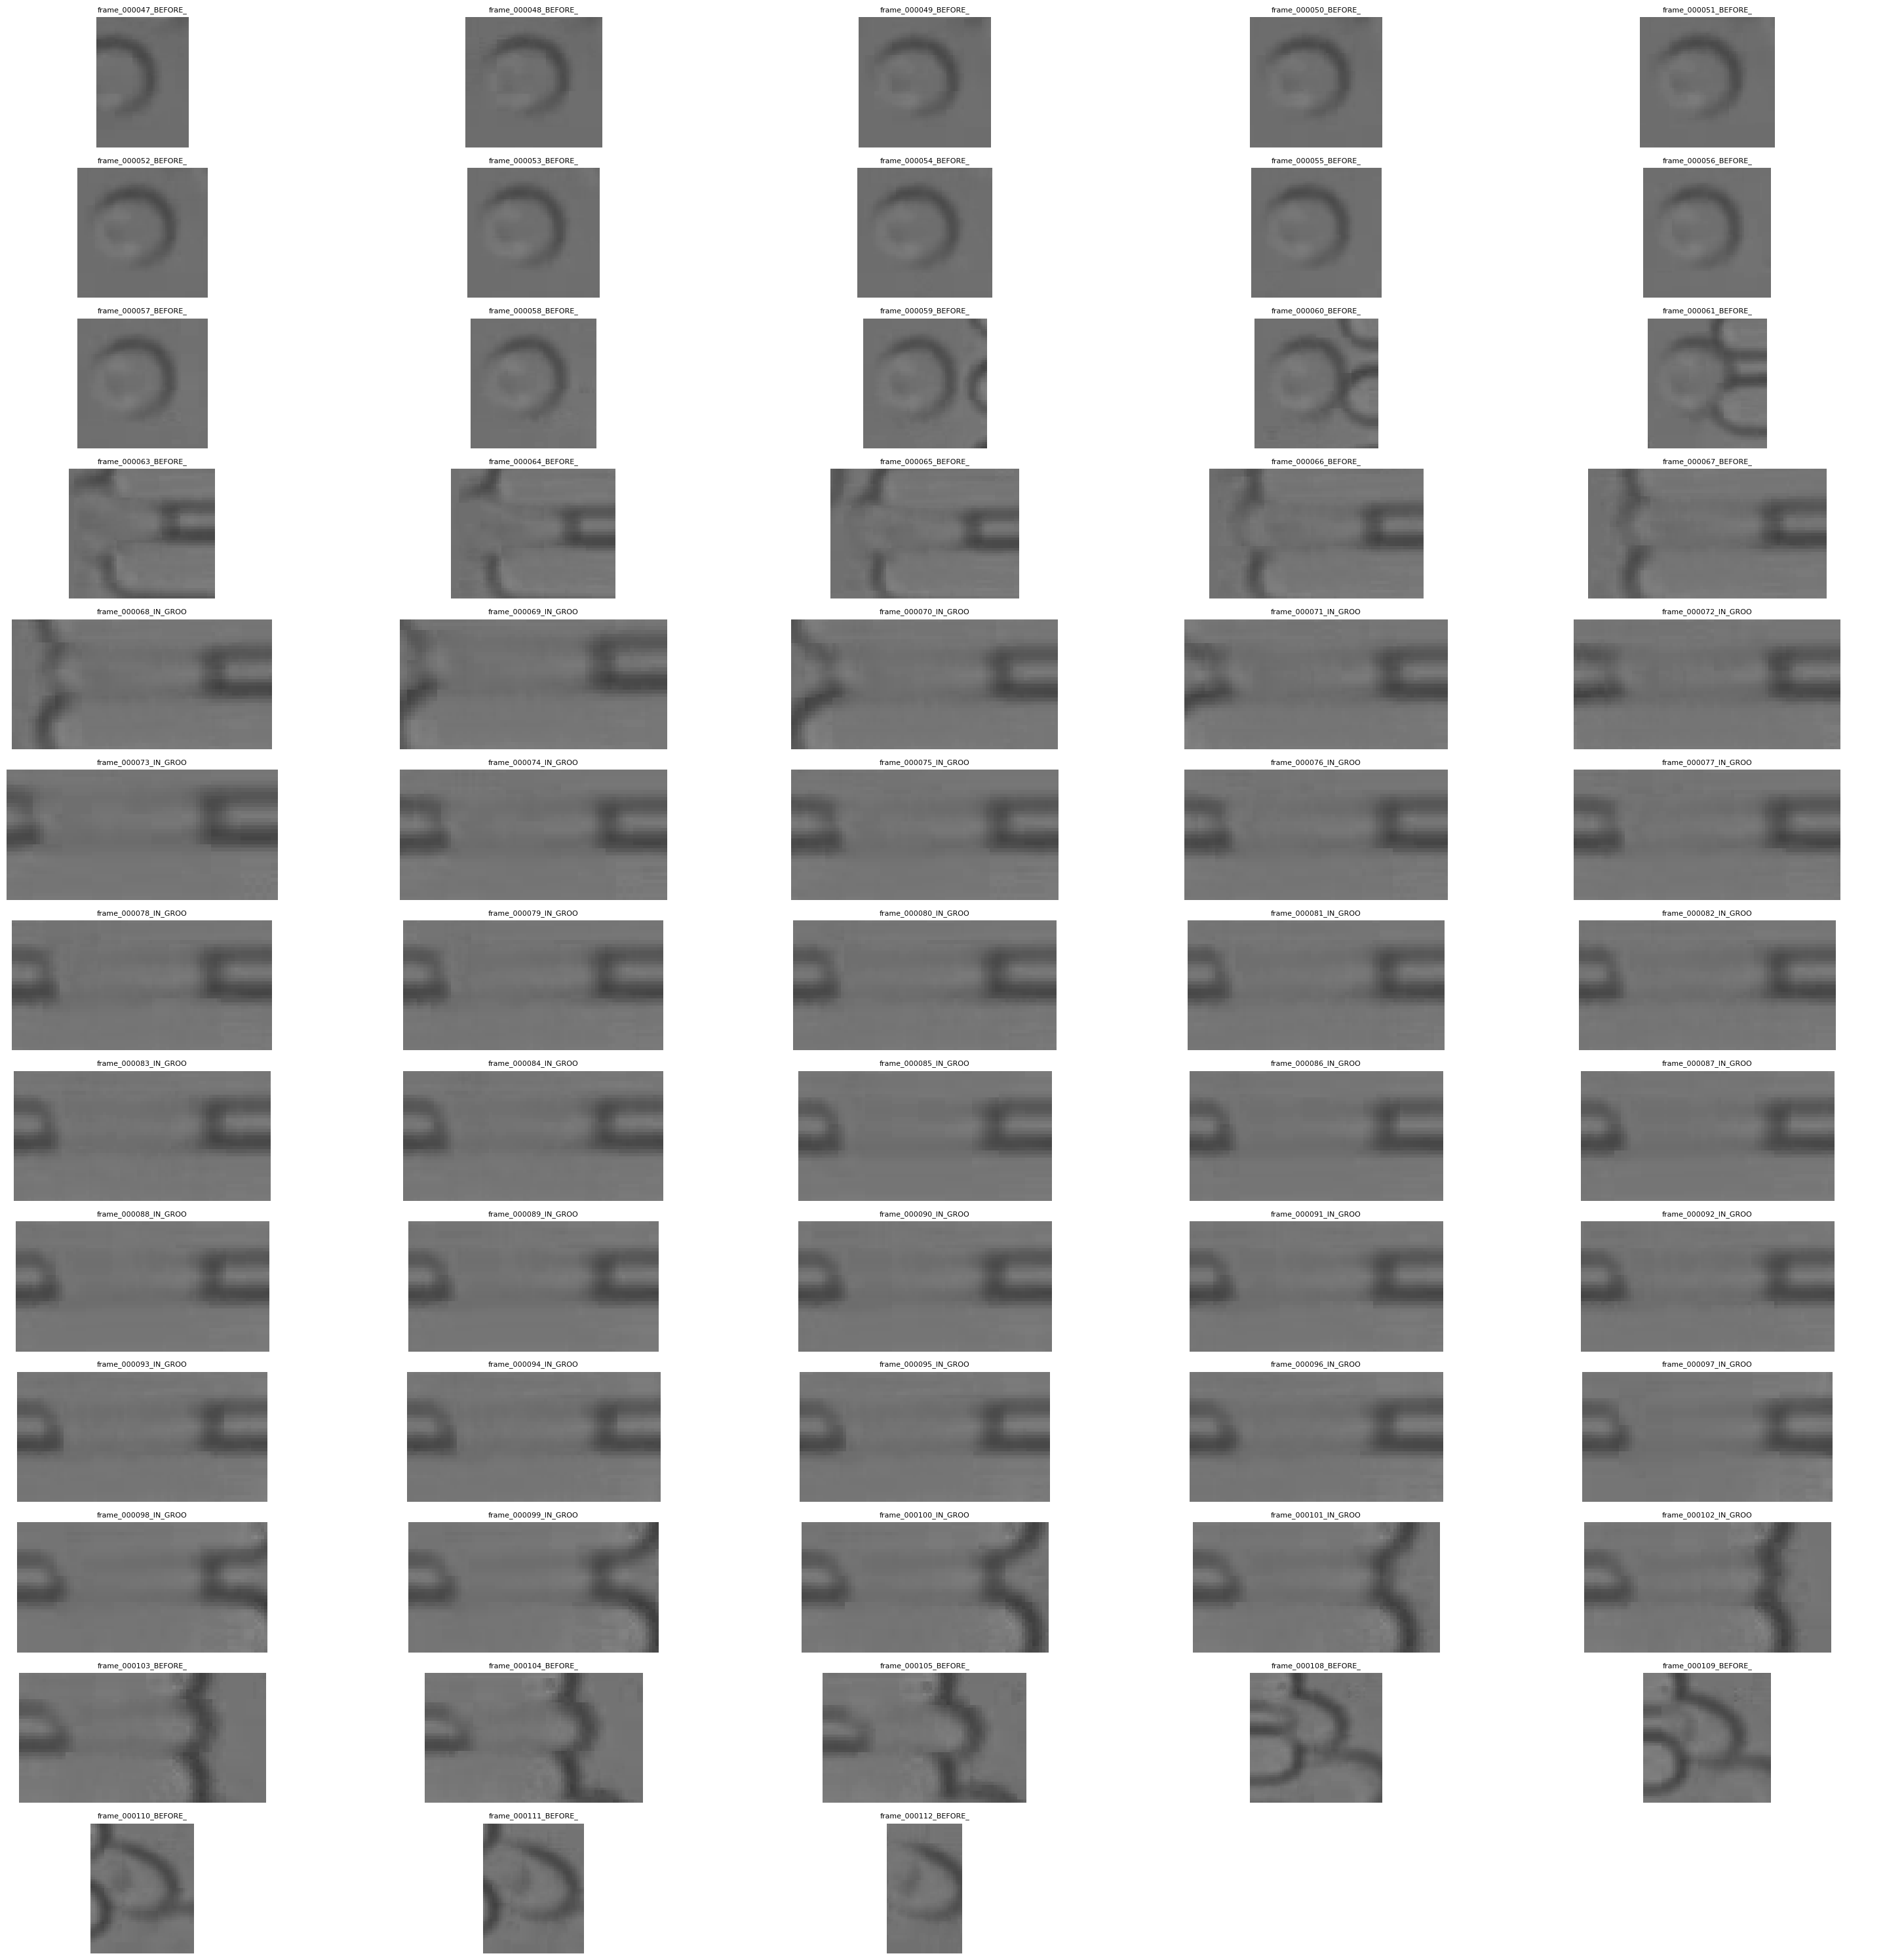

In [99]:
show_images_from_folder("Images/Tracking/erythrocytes_in_groove/ID_166")

In [105]:
results = process_erythrocytes_in_groove(
         background_path="Images/Tracking/enhanced_background.png",
         video_path="Videos/enhanced_video.mp4",
         threshold=15,
         min_area=200,
         max_area=1000,
         max_distance=30,
         max_missing=3,
         groove_top_left=(280, 200),
         groove_bottom_right=(450, 300),
         padding=10,
         output_dir="Images/Tracking/erythrocytes_in_groove_enhanced",
         visualize=True
    )

Clearing output directory: Images/Tracking/erythrocytes_in_groove_enhanced
Output directory cleared
Starting video processing...
Groove area: (280, 200) -> (450, 300)
Crop padding: 10 pixels
Saving ALL erythrocytes that ever entered the groove
------------------------------------------------------------
[ID:12] ENTERED groove at frame 1
[ID:10] ENTERED groove at frame 4
[ID:14] ENTERED groove at frame 6
[ID:48] ENTERED groove at frame 10
[ID:94] ENTERED groove at frame 40
[ID:146] ENTERED groove at frame 68
[ID:254] ENTERED groove at frame 69
[ID:289] ENTERED groove at frame 76
[ID:314] ENTERED groove at frame 81
[ID:310] ENTERED groove at frame 81
[ID:432] ENTERED groove at frame 111
[ID:427] ENTERED groove at frame 120
[ID:491] ENTERED groove at frame 128
[ID:523] ENTERED groove at frame 145
[ID:515] ENTERED groove at frame 148
[ID:552] ENTERED groove at frame 156
[ID:563] ENTERED groove at frame 172
[ID:575] ENTERED groove at frame 179
[ID:618] ENTERED groove at frame 184
[ID:706] E

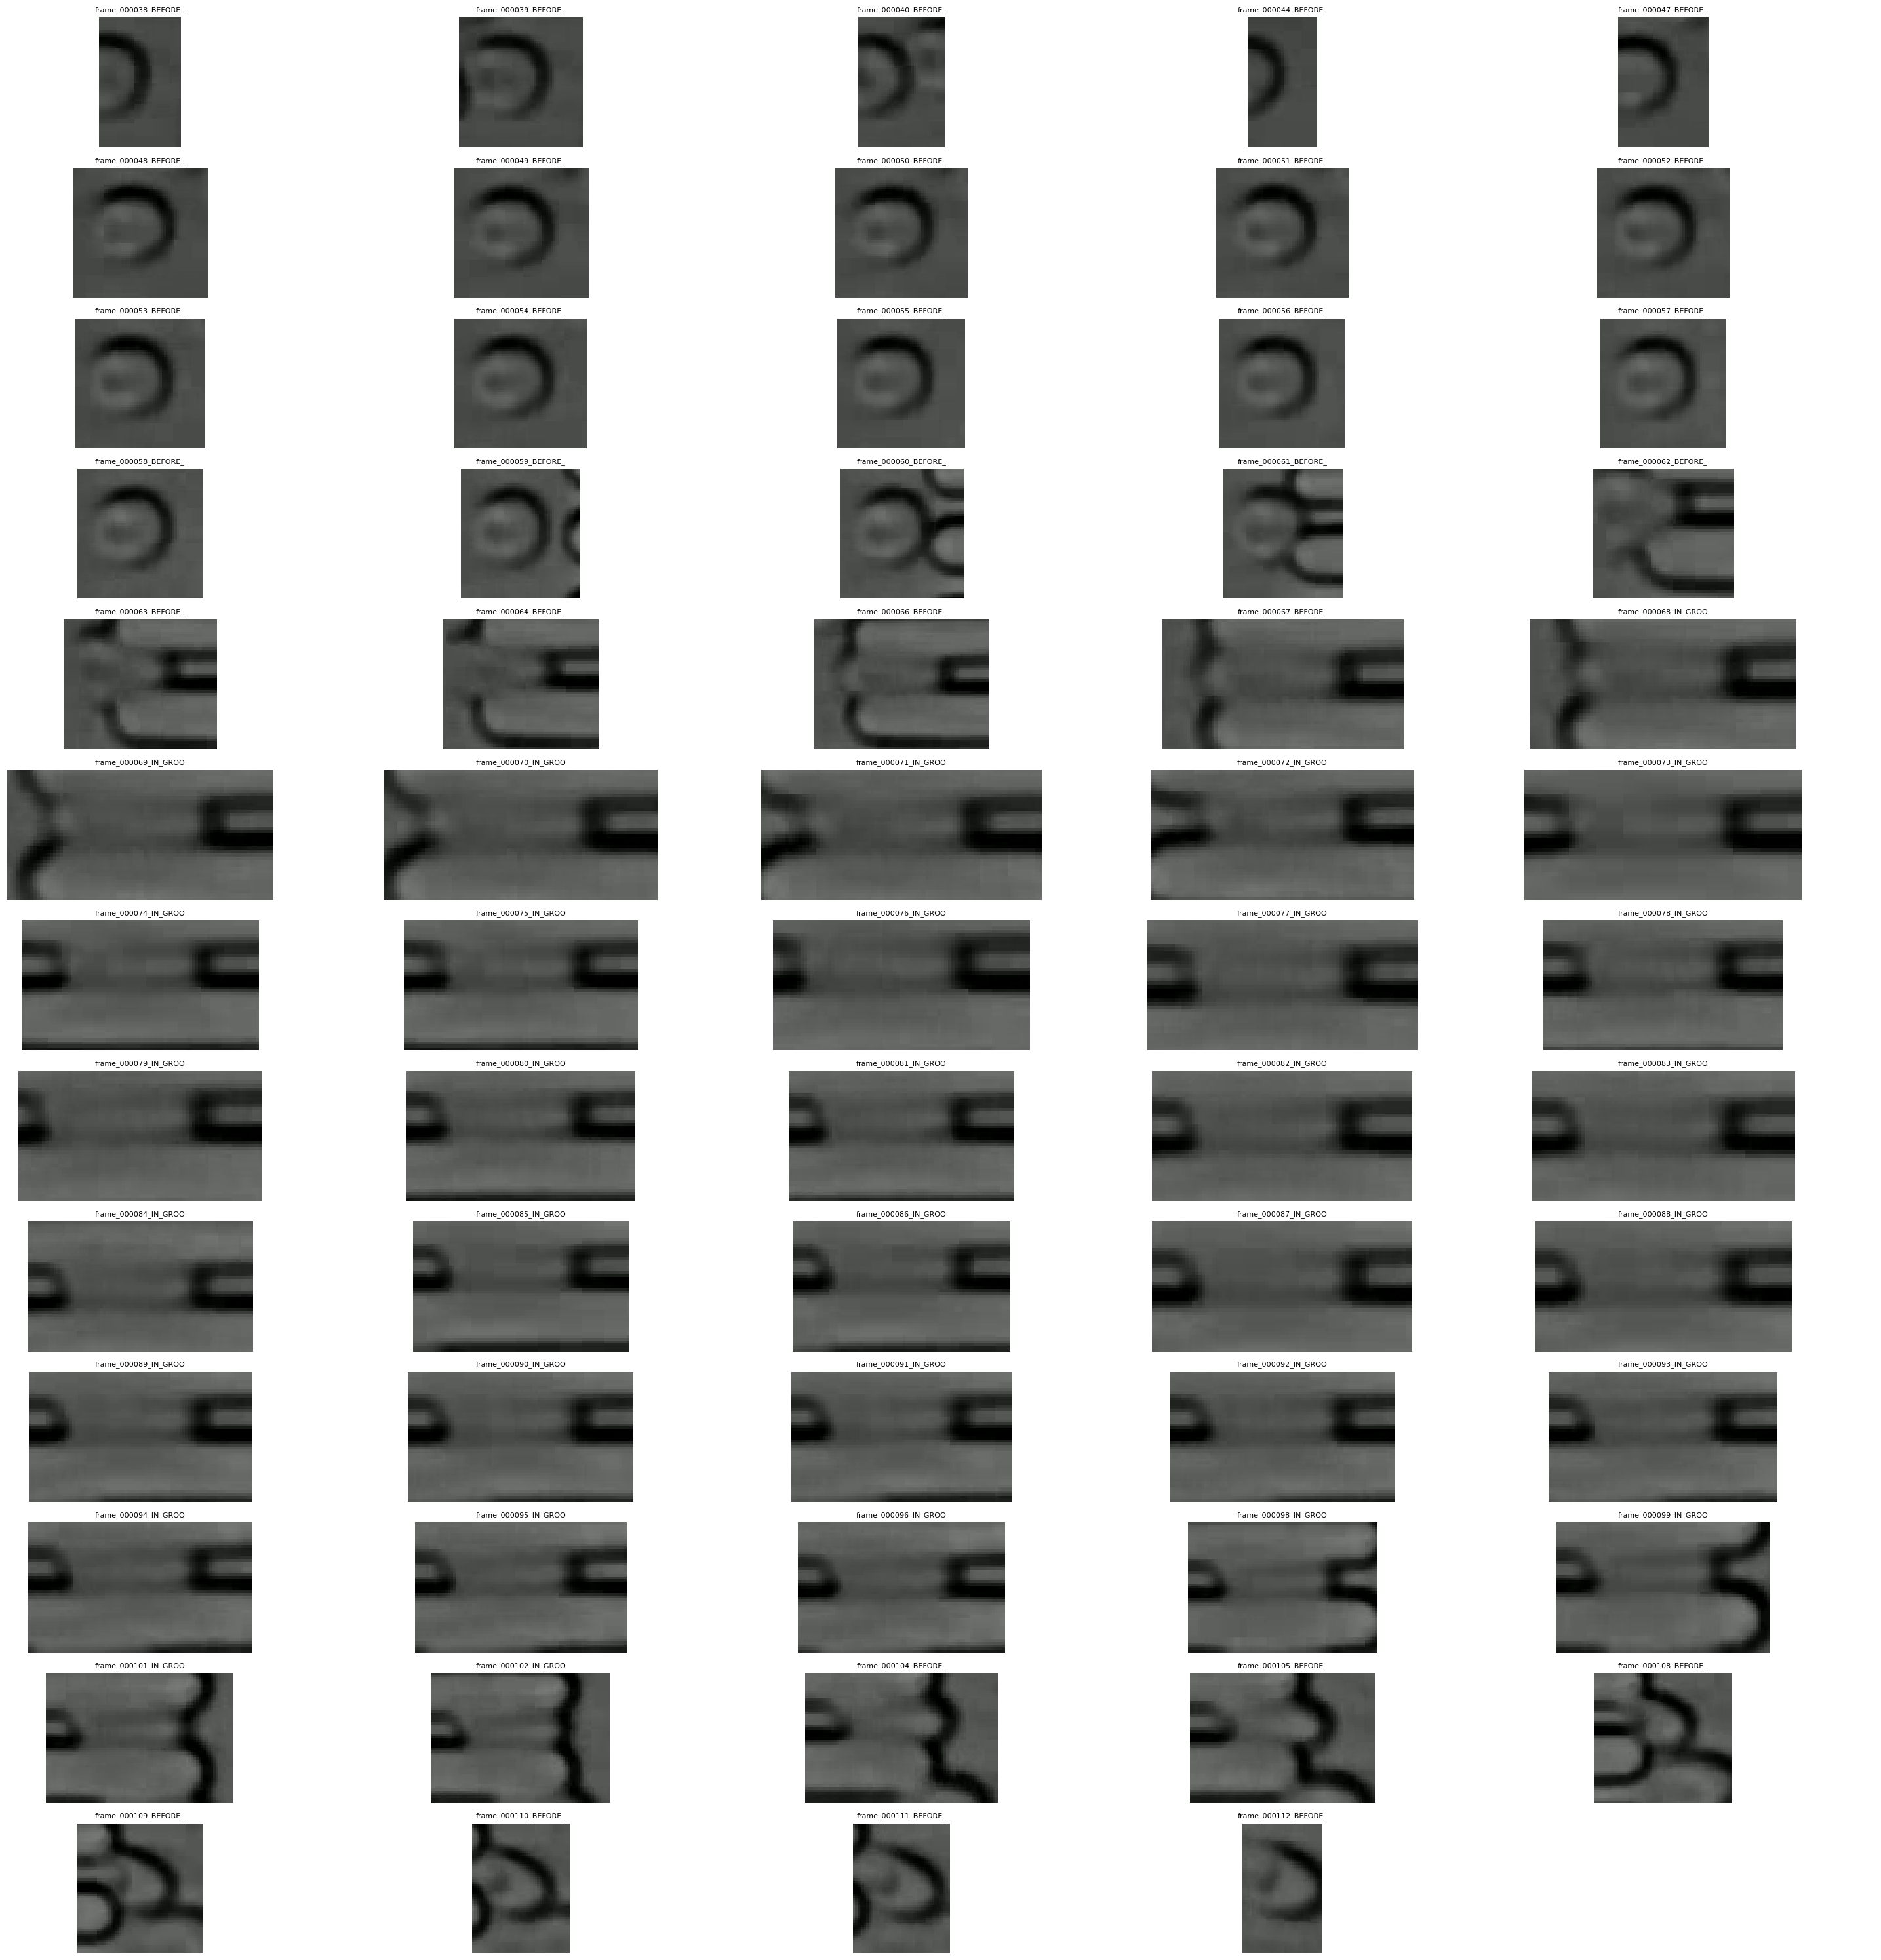

In [109]:
show_images_from_folder("Images/Tracking/erythrocytes_in_groove_enhanced/ID_146")